# Student Dropout Prediction — Model Training and Feature Selection

## Import Library

In [32]:
# Import libraries
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.inspection import permutation_importance
from sklearn.base import clone

import matplotlib.pyplot as plt

## Get Data

In [17]:
# Define project and data paths
current_path = Path.cwd()

if (current_path / "data" / "processed" / "processed.csv").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed.csv"

print("Project root:", PROJECT_ROOT)
print("Processed data path:", PROCESSED_DATA_PATH)
print("Processed dataset exists:", PROCESSED_DATA_PATH.exists())

Project root: c:\Not Default\Projects\student-dropout-prediction-ml
Processed data path: c:\Not Default\Projects\student-dropout-prediction-ml\data\processed\processed.csv
Processed dataset exists: True


In [18]:
# Load processed dataset
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Processed dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Processed dataset loaded successfully.
Dataset shape: (3630, 22)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,13,10,6,10,...,0,1,1,0,20,0,10.8,1.4,1.74,1
1,1,6,1,11,1,1,1,3,4,4,...,0,0,1,0,19,0,13.9,-0.3,0.79,0
2,1,1,5,5,1,1,22,27,10,10,...,0,0,1,0,19,0,10.8,1.4,1.74,1
3,1,8,2,15,1,1,23,27,6,4,...,0,1,0,0,20,0,9.4,-0.8,-3.12,0
4,2,12,1,3,0,1,22,28,10,10,...,0,1,0,0,45,0,13.9,-0.3,0.79,0


In [19]:
# Validate processed dataset
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows after feature removal:", df.duplicated().sum())
print("Target unique values:", sorted(df["Target"].unique()))

df["Target"].value_counts().sort_index()

Dataset shape: (3630, 22)
Missing values: 0
Duplicate rows after feature removal: 4
Target unique values: [np.int64(0), np.int64(1)]


Target
0    2209
1    1421
Name: count, dtype: int64

## Split Data

In [20]:
# Separate features and target
X = df.drop(columns=["Target"])
y = df["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (3630, 21)
y shape: (3630,)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP
0,1,8,5,2,1,1,13,10,6,10,...,0,0,1,1,0,20,0,10.8,1.4,1.74
1,1,6,1,11,1,1,1,3,4,4,...,0,0,0,1,0,19,0,13.9,-0.3,0.79
2,1,1,5,5,1,1,22,27,10,10,...,0,0,0,1,0,19,0,10.8,1.4,1.74
3,1,8,2,15,1,1,23,27,6,4,...,0,0,1,0,0,20,0,9.4,-0.8,-3.12
4,2,12,1,3,0,1,22,28,10,10,...,0,0,1,0,0,45,0,13.9,-0.3,0.79


In [21]:
# Define continuous features
continuous_features = [
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

# Keep only existing continuous features
continuous_features = [
    col for col in continuous_features
    if col in X.columns
]

# Define categorical-like features
categorical_features = [
    col for col in X.columns
    if col not in continuous_features
]

print("Continuous features:", len(continuous_features))
print(continuous_features)

print("\nCategorical-like features:", len(categorical_features))
print(categorical_features)

Continuous features: 4
['Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP']

Categorical-like features: 17
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


In [22]:
# Split dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

X_train shape: (2904, 21)
X_test shape: (726, 21)
y_train shape: (2904,)
y_test shape: (726,)

Train target distribution:
Target
0    0.608471
1    0.391529
Name: proportion, dtype: float64

Test target distribution:
Target
0    0.608815
1    0.391185
Name: proportion, dtype: float64


## Define, Train and Evaluate Model

In [23]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("continuous", StandardScaler(), continuous_features)
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('continuous', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [24]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [25]:
# Define baseline and main classification models
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes (Main Model)": GaussianNB()
}

In [26]:
# Train and evaluate baseline models
evaluation_results = []

trained_models = {}

for model_name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predict class
    y_pred = pipeline.predict(X_test)
    
    # Predict probability for ROC-AUC
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Store trained model
    trained_models[model_name] = pipeline
    
    # Store evaluation metrics
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.761708,0.712644,0.654930,0.682569,0.851611
1,Naive Bayes (Main Model),0.403581,0.392185,0.954225,0.555897,0.498877


In [27]:
# Sort models by ROC-AUC and F1-Score
evaluation_df = evaluation_df.sort_values(
    by=["ROC-AUC", "F1-Score"],
    ascending=False
).reset_index(drop=True)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.761708,0.712644,0.654930,0.682569,0.851611
1,Naive Bayes (Main Model),0.403581,0.392185,0.954225,0.555897,0.498877


In [ ]:
# Show classification report and confusion matrix for each model
for model_name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Graduate", "Dropout"]
    ))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression (Baseline)

Classification Report:
              precision    recall  f1-score   support

    Graduate       0.79      0.83      0.81       442
     Dropout       0.71      0.65      0.68       284

    accuracy                           0.76       726
   macro avg       0.75      0.74      0.75       726
weighted avg       0.76      0.76      0.76       726

Confusion Matrix:
[[367  75]
 [ 98 186]]

Naive Bayes (Main Model)

Classification Report:
              precision    recall  f1-score   support

    Graduate       0.63      0.05      0.09       442
     Dropout       0.39      0.95      0.56       284

    accuracy                           0.40       726
   macro avg       0.51      0.50      0.32       726
weighted avg       0.54      0.40      0.27       726

Confusion Matrix:
[[ 22 420]
 [ 13 271]]

Best model: Logistic Regression (Baseline)


In [30]:
# Select best model based on ROC-AUC
best_model_name = evaluation_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Logistic Regression (Baseline)


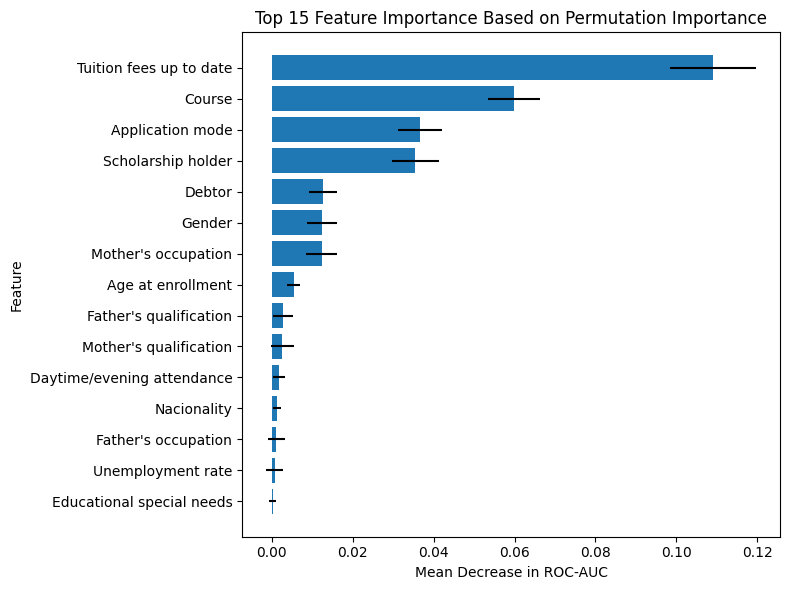

In [36]:
# Select top features for MVP
MVP_FEATURE_COUNT = 10

mvp_features = (
    feature_importance_df[feature_importance_df["importance_mean"] > 0]
    .head(MVP_FEATURE_COUNT)["feature"]
    .tolist()
)

# Visualize top 15 important features
top_features = feature_importance_df.head(15).sort_values(by="importance_mean")

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.title("Top 15 Feature Importance Based on Permutation Importance")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [37]:
# Create MVP train-test feature set
X_train_mvp = X_train[mvp_features].copy()
X_test_mvp = X_test[mvp_features].copy()

# Separate MVP continuous and categorical-like features
mvp_continuous_features = [
    col for col in continuous_features
    if col in mvp_features
]

mvp_categorical_features = [
    col for col in mvp_features
    if col not in mvp_continuous_features
]

print("MVP continuous features:", len(mvp_continuous_features))
print(mvp_continuous_features)

print("\nMVP categorical-like features:", len(mvp_categorical_features))
print(mvp_categorical_features)

print("\nX_train_mvp shape:", X_train_mvp.shape)
print("X_test_mvp shape:", X_test_mvp.shape)

MVP continuous features: 1
['Age at enrollment']

MVP categorical-like features: 9
['Tuition fees up to date', 'Course', 'Application mode', 'Scholarship holder', 'Debtor', 'Gender', "Mother's occupation", "Father's qualification", "Mother's qualification"]

X_train_mvp shape: (2904, 10)
X_test_mvp shape: (726, 10)


In [38]:
# Build MVP preprocessing pipeline
mvp_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), mvp_categorical_features),
        ("continuous", StandardScaler(), mvp_continuous_features)
    ],
    remainder="drop"
)

# Clone the best model estimator
mvp_estimator = clone(models[best_model_name])

# Create MVP pipeline
mvp_pipeline = Pipeline(steps=[
    ("preprocessor", mvp_preprocessor),
    ("model", mvp_estimator)
])

# Train MVP model
mvp_pipeline.fit(X_train_mvp, y_train)

mvp_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('continuous', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [39]:
# Evaluate MVP model
y_pred_mvp = mvp_pipeline.predict(X_test_mvp)
y_proba_mvp = mvp_pipeline.predict_proba(X_test_mvp)[:, 1]

mvp_evaluation = {
    "Model": "MVP Model",
    "Accuracy": accuracy_score(y_test, y_pred_mvp),
    "Precision": precision_score(y_test, y_pred_mvp),
    "Recall": recall_score(y_test, y_pred_mvp),
    "F1-Score": f1_score(y_test, y_pred_mvp),
    "ROC-AUC": roc_auc_score(y_test, y_proba_mvp)
}

mvp_evaluation_df = pd.DataFrame([mvp_evaluation])

mvp_evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,MVP Model,0.769972,0.733068,0.647887,0.68785,0.857948


In [40]:
# Compare full best model and MVP model
best_model_result = evaluation_df[evaluation_df["Model"] == best_model_name].copy()

model_comparison_df = pd.concat(
    [best_model_result, mvp_evaluation_df],
    ignore_index=True
)

model_comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.761708,0.712644,0.654930,0.682569,0.851611
1,MVP Model,0.769972,0.733068,0.647887,0.687850,0.857948
